In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from quspin.operators import hamiltonian
from DSF import *

In [5]:
N = 7
Temp = np.linspace(0.2, 3.7, 35)
beta = 1/Temp
T = np.linspace(0, 100, 1001)
w = np.linspace(0, 6, 601)
# k_d = 120
# N_samples = 5

basis, r = build_basis(N, "1")
H = H_heisenburg(N, 0.7, basis, obc=True)
[E0] = H.eigsh(k=1, which="SA", maxiter=1e4, return_eigenvectors=False)
# psi_0 = psi_0.flatten()
# print(E0)

S1_list = []
S2_list = []
# momentum space at k = Q
# Q = np.pi
# for i in range(N):
#     S1_list.append([1/(N)**0.5 * np.exp(1j* Q*r[i]), i])
#     # S2_list.append([1/(N)**0.5 * np.exp(-1j* Q*r[i]), i])
#     S2_list.append([0, i])
# S2_list[3][0] = 1/(N)**0.5 * np.exp(-1j* Q*r[3])
# Si = 4
for i in range(N):
    S1_list.append([0, i])
    S2_list.append([1/N, i])
# S1_list[Si][0] = 1
# S2_list[Si][0] = 1


Sz1 = hamiltonian([["z", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sz2 = hamiltonian([["z", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)

# Szz, Z = dsf_lanczos(Sz1, Sz2, H, E0, k_d, N_samples, w, beta=beta)
# Szz_T0_L = dsf_lanczos_T0(Sz1, Sz2, H, E0, k_d, N_samples, w)
# Szz, Z = dsf_lanczos_src([Sz1], [Sz2], H, E0, psi_0, k_d, N_samples, w, beta=[10/1])

E_0, V_0, Szz_full, Z_full, Szz_full_T0, M = dsf_exact(Sz1, Sz2, H, w, beta)
# E_0, V_0, Szz_full, Z_full, Szz_full_T0, M = dsf_xt_exact(Sz1, Sz2, H, T, beta)

Hilbert space size: 2187.

Hermiticity check passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
E0 = -11.899999999999997


In [8]:
dmrg = pd.read_csv('/home/amos1/tensornetwork/Sq_data/17_S1.0_h0.70_Oxt_Oyt_psi-9_db0.01_QNt_k24.csv')
Temp_DMRG = 1/dmrg.beta 

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


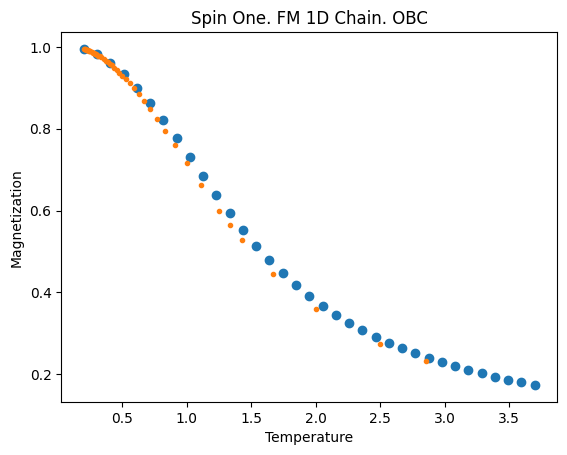

In [9]:
fig, ax = plt.subplots()

ax.scatter(Temp, M)
ax.scatter(Temp_DMRG, dmrg.Sz, marker='.')

ax.set_xlabel('Temperature')
ax.set_ylabel('Magnetization')

# ax.set_ylim(-0.01, 1.01)
ax.set_title("Spin One. FM 1D Chain. OBC")
plt.show()

In [10]:
for i in range(3):
    print(f"beta={beta[i]}, Mz={M[i]/Z_full[i]}")


beta=0.1, Mz=(-0.026223778645856274+0j)
beta=0.01, Mz=(-0.0025124786439358056+0j)
beta=0.001, Mz=(-0.0002501249791148266+0j)


# real space plot

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


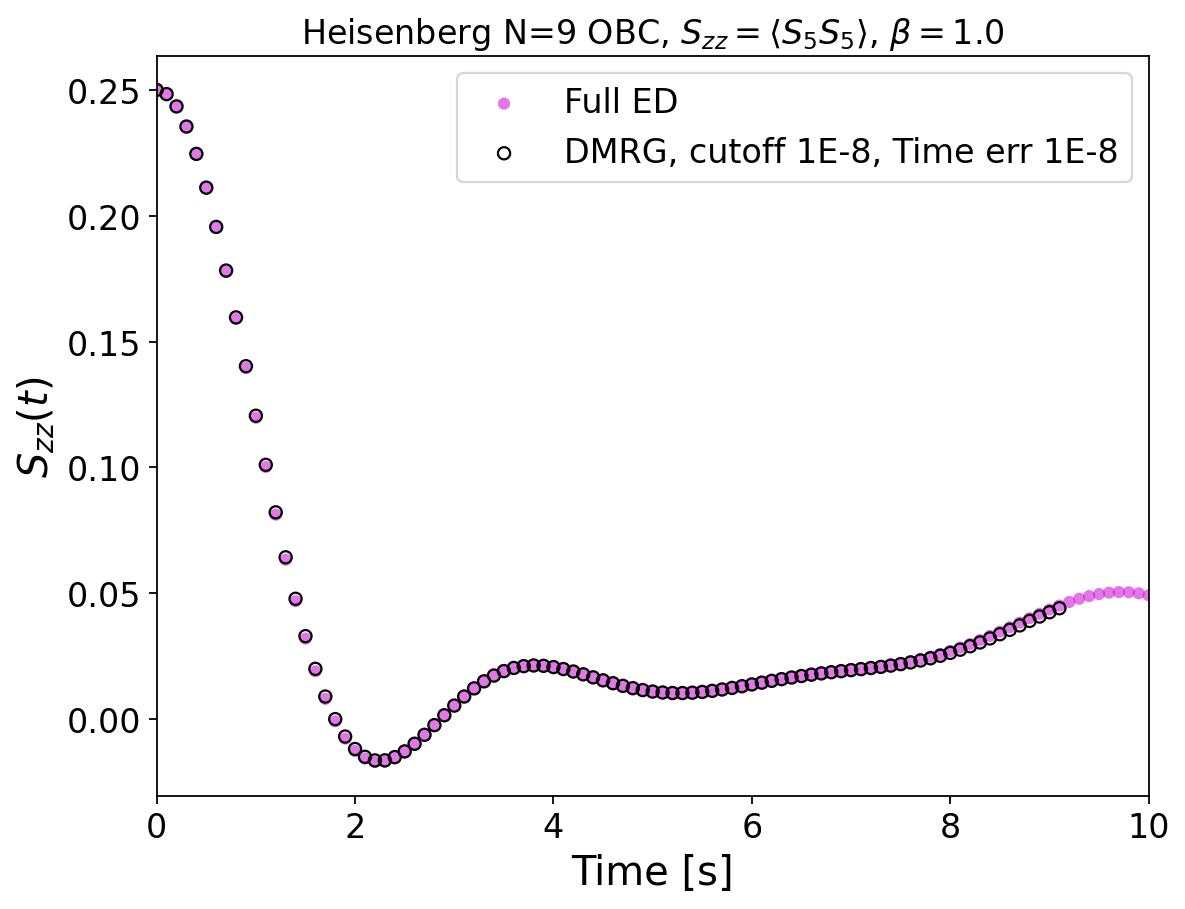

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

ax.scatter(T, Szz_full.flatten()/Z_full, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")
# ax.scatter(T, Szz_full_T0.flatten(), 
#     s=30, marker="o", c="#CC0FD690", edgecolors='none',
#     label="Full ED, T=0")

# dmrg = pd.read_csv("./Heisenberg_data/S_N9_k1.00_T5_dt0.05_beta0.01_zz.csv")
# ax.scatter(w, dmrg.RS/100,
#     marker="h", c="#29CCE9FF", edgecolors="#FF1418C8", linewidths=0.8, s=36, 
#     label=f"scaled DMRG, T=5"
#     )
dmrg = pd.read_csv("./Heisenberg_data/Chi_N9_S5S5_Tau10_dt0.05_beta1.00_zz_err-8_dbeta0.01.csv")
ax.scatter(dmrg.t, dmrg.RS,
    s=30, marker="o", c="none", edgecolors='k', 
    label=f"DMRG, cutoff 1E-8, Time err 1E-8"
    )


ax.legend(fontsize=15)
ax.set_xlabel("Time [s]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(t)$", fontsize=18)
ax.set_xlim(0, 10)
# ax.set_ylim(-0.2, 2.5)
# ax.set_ylim(-0.01, 0.1)
ax.tick_params(axis='both', labelsize=15)
# {beta[0]}
ax.set_title(f"Heisenberg N={N} OBC, $S_{{zz}} = \\langle S_{Si+1} S_{Si+1}\\rangle$, $\\beta={beta[0]}$", fontsize=15)
plt.show()

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


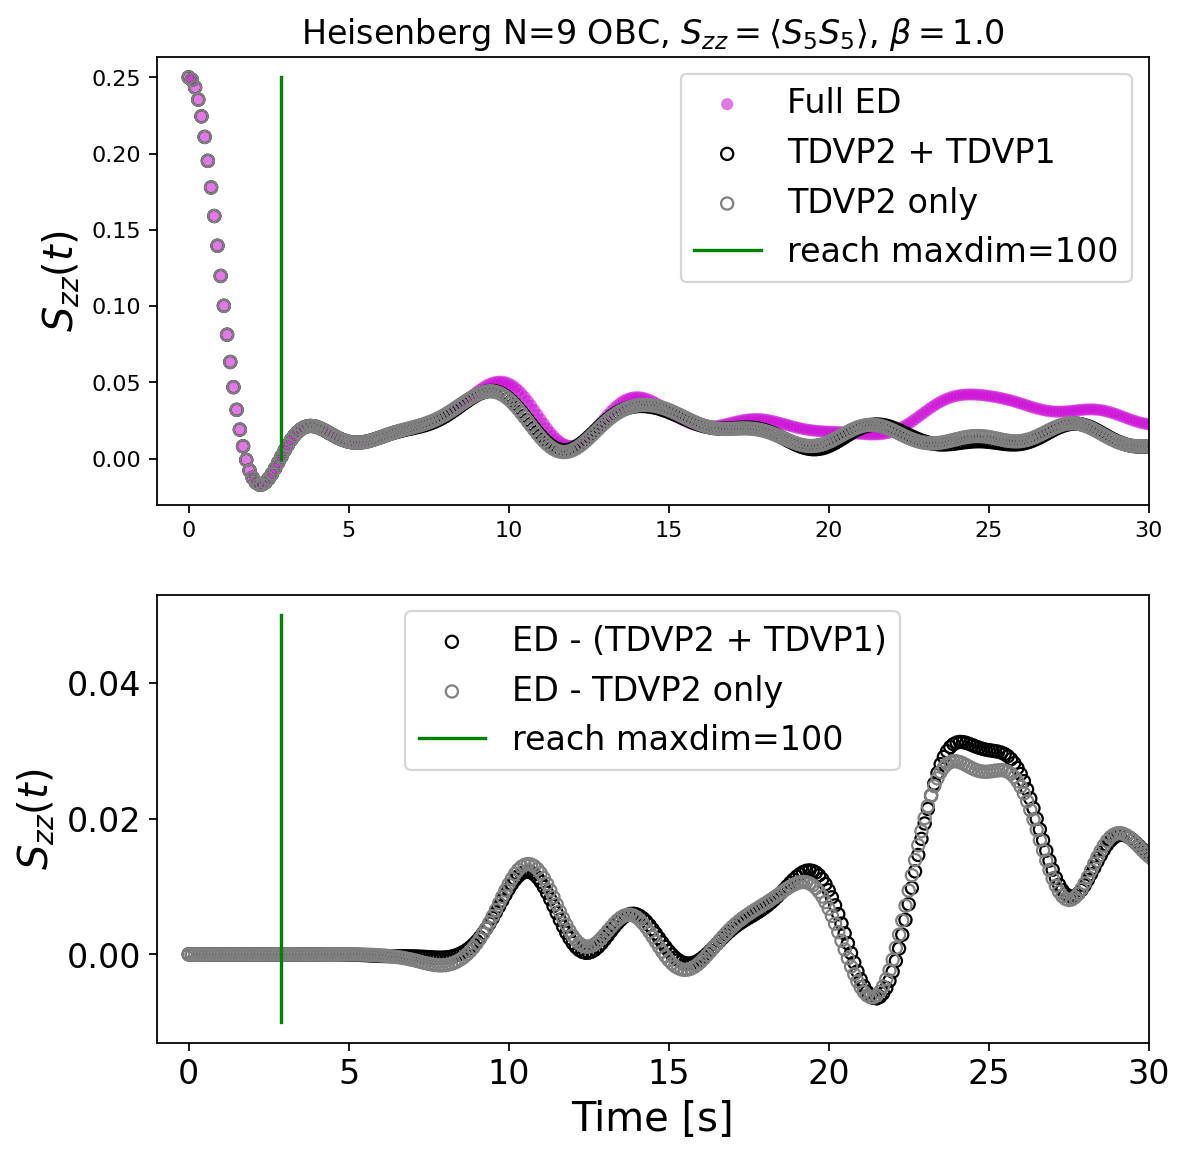

In [21]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), dpi=160)

ED_data = Szz_full.flatten()/Z_full
dmrg_folder = "./Heisenberg_data/v2/"
ax = axs[0]
ax.scatter(T, ED_data, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")
dmrg21 = pd.read_csv(dmrg_folder + "Chi_N9_pbc_S5S5_Tau100_dt0.05_beta1.00_zz_test2+1.csv")
ax.scatter(dmrg21.t, dmrg21.RS,
    s=30, marker="o", c="none", edgecolors='k', 
    label=f"TDVP2 + TDVP1"
    )
dmrg22 = pd.read_csv(dmrg_folder + "Chi_N9_pbc_S5S5_Tau100_dt0.05_beta1.00_zz_test2+2.csv")
ax.scatter(dmrg22.t, dmrg22.RS,
    s=30, marker="o", c="none", edgecolors='grey', 
    label=f"TDVP2 only"
    )
ax.plot([2.9, 2.9], [0, 0.25], color='g', label="reach maxdim=100")

ax = axs[1]
ax.scatter(dmrg21.t, (ED_data - dmrg21.RS),
    s=30, marker="o", c="none", edgecolors='k', 
    label=f"ED - (TDVP2 + TDVP1)"
    )
ax.scatter(dmrg22.t, (ED_data - dmrg22.RS),
    s=30, marker="o", c="none", edgecolors='grey', 
    label=f"ED - TDVP2 only"
    )
ax.plot([2.9, 2.9], [-0.01, 0.05], color='g', label="reach maxdim=100")

axs[0].legend(fontsize=15)
axs[1].legend(fontsize=15)
axs[1].set_xlabel("Time [s]", fontsize=18)
axs[0].set_ylabel("$S_{{zz}}(t)$", fontsize=18)
axs[1].set_ylabel("$S_{{zz}}(t)$", fontsize=18)
axs[0].set_xlim(-1, 30)
axs[1].set_xlim(-1, 30)
axs[1].tick_params(axis='both', labelsize=15)

axs[0].set_title(f"Heisenberg N={N} OBC, $S_{{zz}} = \\langle S_{Si+1} S_{Si+1}\\rangle$, $\\beta={beta[0]}$", fontsize=15)
plt.show()

# Momentum space

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


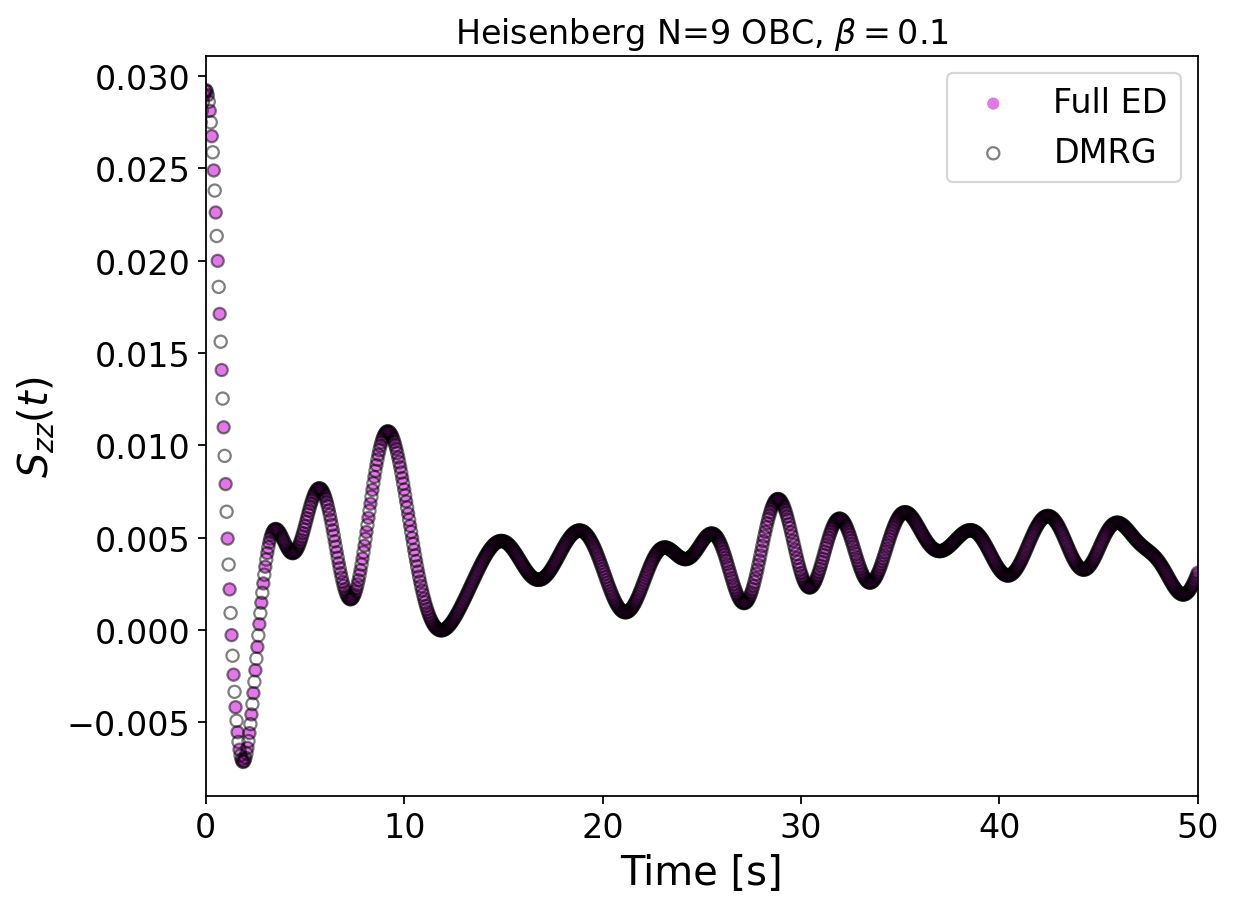

In [76]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

ax.scatter(T, Szz_full.flatten()/Z_full, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")
dmrg = pd.read_csv("./Heisenberg_data/Chi_N9_k1.00_Tau50_dt0.05_beta0.10_zz_err-10.csv")
ax.scatter(dmrg.t, dmrg.RS/9,
    s=30, marker="o", c="none", edgecolors='k', alpha=0.5,
    label=f"DMRG"
    )

ax.legend(fontsize=15)
ax.set_xlabel("Time [s]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(t)$", fontsize=18)
ax.set_xlim(0, 50)
ax.tick_params(axis='both', labelsize=15)

# {beta[0]}
ax.set_title(f"Heisenberg N={N} OBC, $\\beta={beta[0]}$", fontsize=15)
plt.show()

# Energy, purity

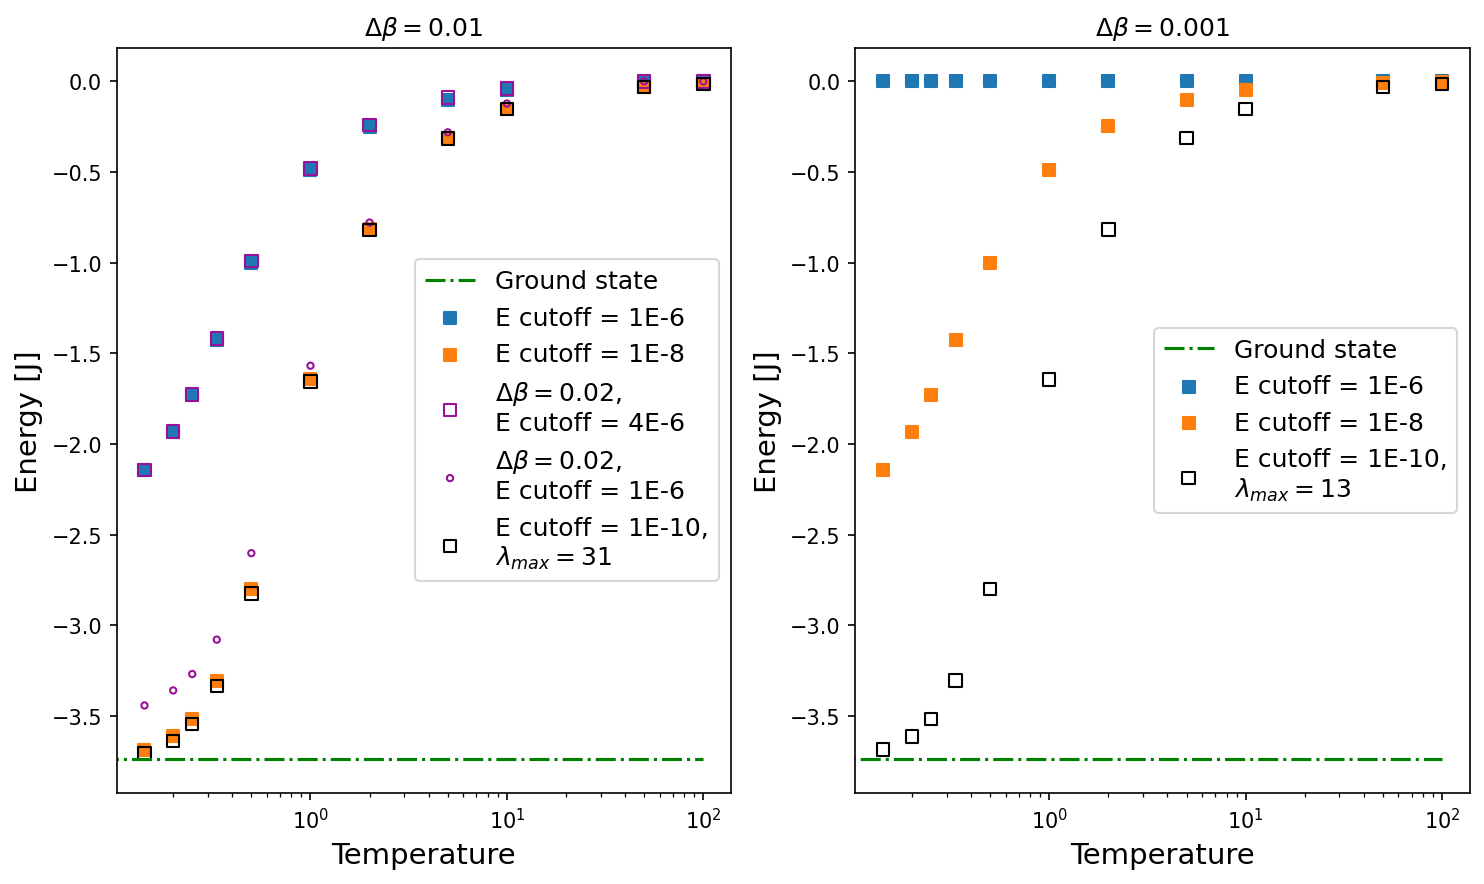

In [12]:
folder = "./Heisenberg_data/v1/"
data6 = pd.read_csv(folder+"N9_E_cut-6.csv")
data8 = pd.read_csv(folder+"N9_E_cut-8.csv")
data10 = pd.read_csv(folder+"N9_E_cut-10.csv")
data6p = pd.read_csv(folder+"N9_E_cut-6_dbeta0.001.csv")
data8p = pd.read_csv(folder+"N9_E_cut-8_dbeta0.001.csv")
data10p = pd.read_csv(folder+"N9_E_cut-10_dbeta0.001.csv")
data46 = pd.read_csv(folder+"N9_E_cut4-6_dbeta0.02.csv")
data16 = pd.read_csv(folder+"N9_E_cut1-6_dbeta0.02.csv")
T = 1/data10.beta 

fig, axs = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

ax = axs[0]
ax.plot([0, 100], [data10.E[0], data10.E[0]], ls="-.", label="Ground state", c='g')
ax.scatter(T[1:], data6.E[1:], marker="s", label="E cutoff = 1E-6")
ax.scatter(T[1:], data8.E[1:], marker="s", label="E cutoff = 1E-8")
ax.scatter(T[1:], data46.E[1:], marker="s", c="none", edgecolors='#991199', 
    label="$\\Delta\\beta = 0.02$, \nE cutoff = 4E-6")
ax.scatter(T[1:], data16.E[1:], marker=".", c="none", edgecolors='#991199', 
    label="$\\Delta\\beta = 0.02$, \nE cutoff = 1E-6")
ax.scatter(T[1:], data10.E[1:], marker="s", c="none", edgecolors='k', 
    label="E cutoff = 1E-10,\n$\\lambda_{max}=31$")

ax.set_title("$\\Delta\\beta = 0.01$")

ax = axs[1]
ax.plot([0, 100], [data10p.E[0], data10p.E[0]], ls="-.", label="Ground state", c='g')
ax.scatter(T[1:], data6p.E[1:], marker="s", label="E cutoff = 1E-6")
ax.scatter(T[1:], data8p.E[1:], marker="s", label="E cutoff = 1E-8")
ax.scatter(T[1:], data10p.E[1:], marker="s", c="none", edgecolors='k',
    label="E cutoff = 1E-10,\n$\\lambda_{max}=13$")

ax.set_title("$\\Delta\\beta = 0.001$")

for ax in axs:
    ax.legend(fontsize=12)
    ax.set_xlabel("Temperature", fontsize=14)
    ax.set_ylabel("Energy [J]", fontsize=14)
    # ax.set_xlim(0, 1.1)
    ax.set_xscale('log')
# fig.suptitle("2x2", fontsize=18)
plt.tight_layout()
plt.show()

In [6]:
A = 1-np.exp(0.001/2)
B = 1-np.exp(0.01/2)
C = 1-np.exp(0.02/2)
A/B, A/C

(np.float64(0.09977515004209285), np.float64(0.04976285634332379))

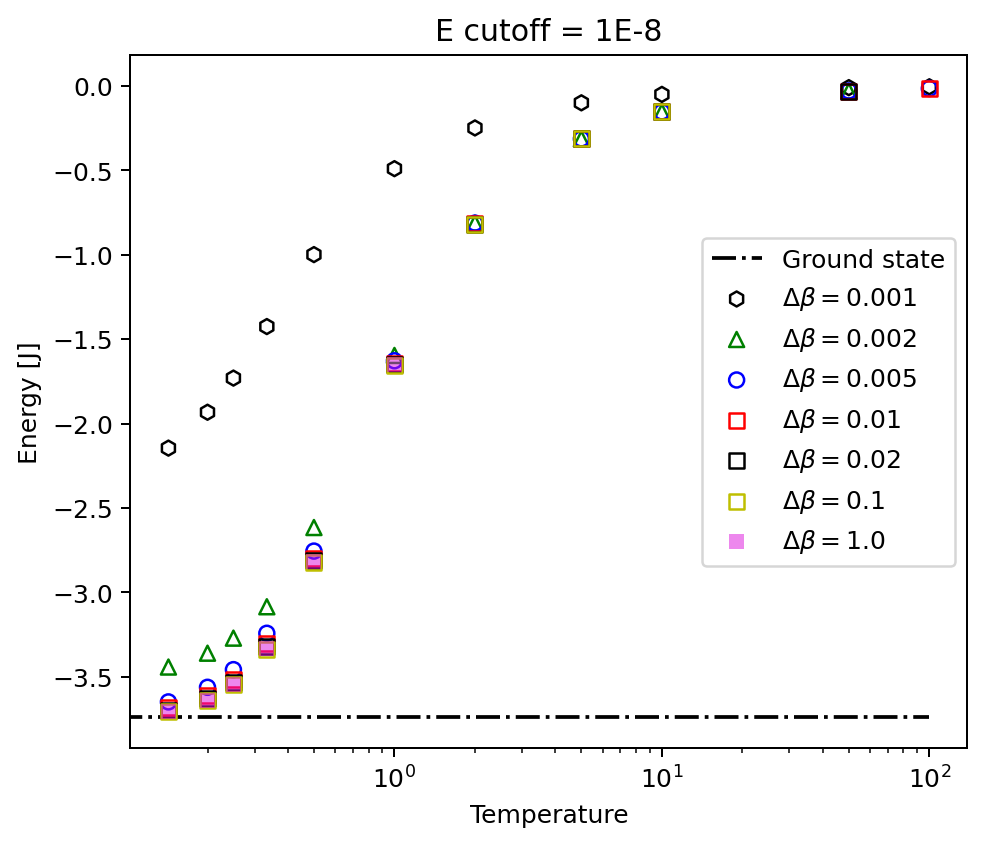

In [36]:
data8a = pd.read_csv("./Heisenberg_data/N9_E_cut-8_dbeta0.001.csv")
data8e = pd.read_csv("./Heisenberg_data/N9_E_cut-8_dbeta0.002.csv")
data8b = pd.read_csv("./Heisenberg_data/N9_E_cut-8_dbeta0.005.csv")
data8c = pd.read_csv("./Heisenberg_data/N9_E_cut-8.csv")
data8d = pd.read_csv("./Heisenberg_data/N9_E_cut-8_dbeta0.02.csv")
data8f = pd.read_csv("./Heisenberg_data/N9_E_cut-8_dbeta0.1.csv")
data8g = pd.read_csv("./Heisenberg_data/N9_E_cut-8_dbeta1.0.csv")
T = 1/data8c.beta

fig, ax = plt.subplots(figsize=(6, 5), dpi=180)

ax.plot([0, 100], [data8c.E[0], data8c.E[0]], ls="-.", label="Ground state", c='k', zorder=1)
ax.scatter(T[1:], data8a.E[1:], marker="h", c="none", edgecolors='k', label="$\\Delta\\beta = 0.001$")
ax.scatter(T[2:], data8e.E[1:], marker="^", c="none", edgecolors='g', label="$\\Delta\\beta = 0.002$")
ax.scatter(T[1:], data8b.E[1:], marker="o", c="none", edgecolors='b', label="$\\Delta\\beta = 0.005$")
ax.scatter(T[1:], data8c.E[1:], marker="s", c="none", edgecolors='r', label="$\\Delta\\beta = 0.01$")
ax.scatter(T[2:], data8d.E[1:], marker="s", c="none", edgecolors='k', label="$\\Delta\\beta = 0.02$")
ax.scatter(T[3:], data8f.E[1:], marker="s", c="none", edgecolors='y', label="$\\Delta\\beta = 0.1$")
ax.scatter(T[6:], data8g.E[1:], marker="s", c="#DD11DD", edgecolors='none', alpha=0.5, label="$\\Delta\\beta = 1.0$")

ax.legend()
ax.set_xlabel("Temperature")
ax.set_ylabel("Energy [J]")
ax.set_xscale('log')
ax.set_title("E cutoff = 1E-8")
plt.show()

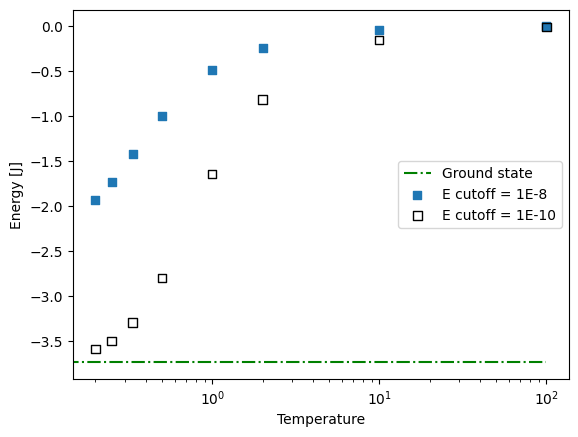

In [11]:
data8 = pd.read_csv("./Heisenberg_data/N9_E_cut-8.csv")
data10 = pd.read_csv("./Heisenberg_data/N9_E_cut-10.csv")
T8 = 1/data8.beta
T10 = 1/data10.beta 

fig, ax = plt.subplots()

ax.plot([0, 100], [data8.E[0], data8.E[0]], ls="-.", label="Ground state", c='g')
ax.scatter(T8[1:], data8.E[1:], marker="s", label="E cutoff = 1E-8")
ax.scatter(T10[1:], data10.E[1:], marker="s", c="none", edgecolors='k', label="E cutoff = 1E-10")

ax.legend()
ax.set_xlabel("Temperature")
ax.set_ylabel("Energy [J]")
ax.set_xscale('log')
plt.show()

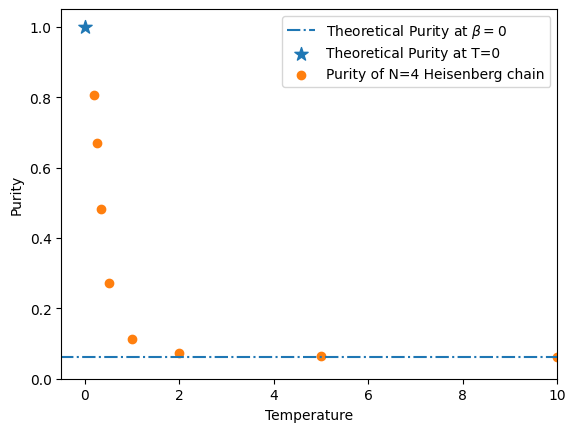

In [16]:
data = pd.read_csv("./Heisenberg_data/N4_purity.csv")
T = 1/data.beta 

fig, ax = plt.subplots()

ax.plot([-1, 101], [1/16, 1/16], label="Theoretical Purity at $\\beta=0$", ls="-.")
ax.scatter(0.001, 1, marker="*", s=100, label="Theoretical Purity at T=0")
ax.scatter(T, data.rho2, marker="o", label="Purity of N=4 Heisenberg chain")

ax.legend()
ax.set_xlim(-0.5, 10)
ax.set_ylim(0, 1.05)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel("Temperature")
ax.set_ylabel("Purity")
plt.show()

# FF space plot

In [62]:
data = pd.read_csv("./Heisenberg_data/Chi_N9_k1.00_Tau50_dt0.05_beta0.10_zz_err-10.csv")
chi = list(data.RS)
Time = list(data.t)
dt = 0.05
S = []
for idx, omega in enumerate(w):
    int_sum = 0
    for i in range(len(Time)):
        int_sum += np.exp(1j * omega * Time[i]) * chi[i]
    S.append(int_sum*dt)

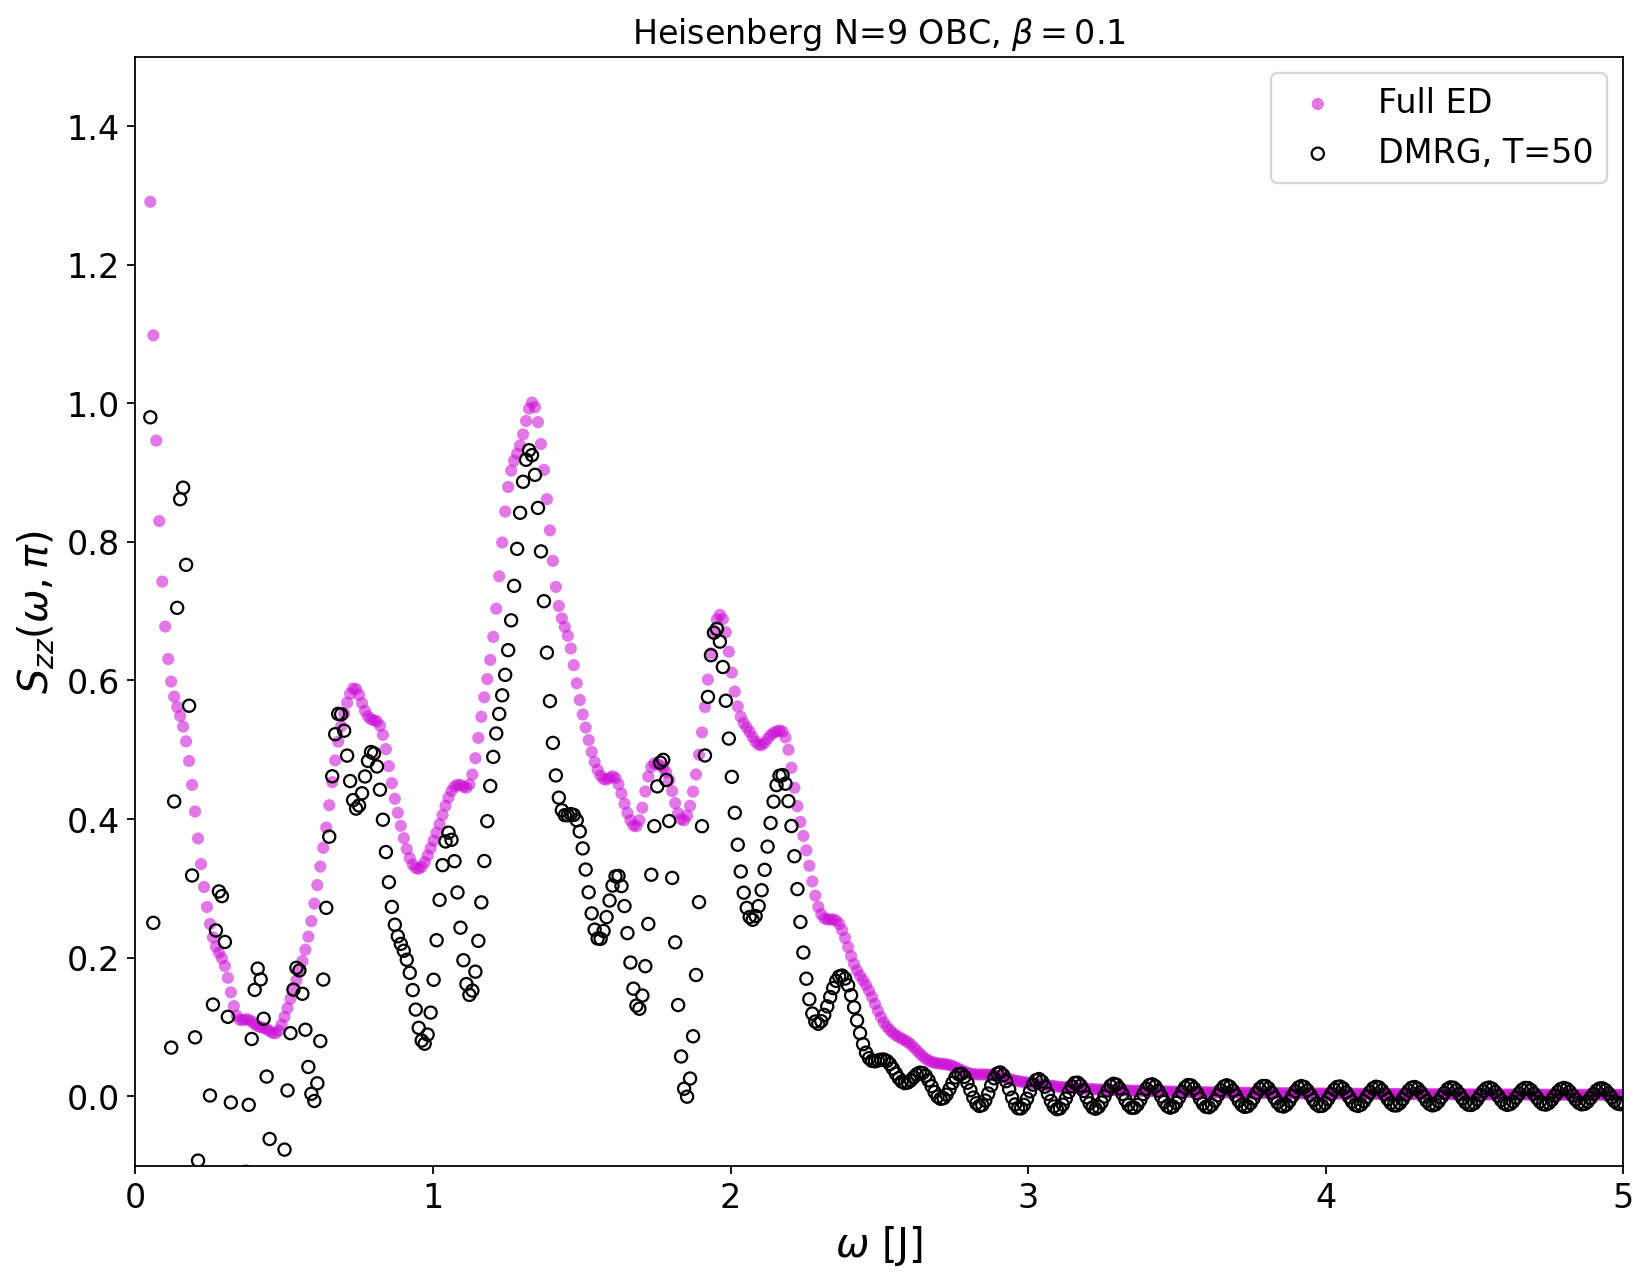

In [66]:
fig, ax = plt.subplots(figsize=(12, 9), dpi=160)

# for i in range(N_samples):
#     if i == 0: label = "Lanczos ED samples"
#     else: label = None
#     ax.scatter(w, Szz[i]/Z[i],
#         s=5, alpha=0.1, c="#F03333", label=label)
    
# ax.scatter(w, a3, 
#     s=20, marker="D", c="#F192E6DE", edgecolors='#F03333',
#     label="Mean Lanczos samples")

ax.scatter(w, Szz_full.flatten()/Z_full*81, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")

ax.scatter(w, S,
    s=30, marker="o", c="none", edgecolors='k', alpha=1, 
    label=f"DMRG, T=50"
    )

ax.legend(fontsize=15)
ax.set_xlabel("$\\omega$ [J]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(\\omega, \\pi)$", fontsize=18)
ax.set_xlim(0, 5)
# ax.set_ylim(-0.2, 2.5)
ax.set_ylim(-0.1, 1.5)
# ax.set_ylim(-0.001, 0.015)
ax.tick_params(axis='both', labelsize=15)

# ax.set_title(f"Heisenberg N={N} PBC, $S_{{zz}} = \\sum_i \\langle S_i S_5\\rangle$, $\\beta={beta[0]}$", fontsize=15)
ax.set_title(f"Heisenberg N={N} OBC, $\\beta={beta[0]}$", fontsize=15)
plt.show()